# Notebook 16: MedKGI-Style Graph Algorithmic Evidence Ledger Offline Analysis

This notebook is the first algorithmic evidence-ledger version for the DDXPlus project.

It is **offline-only**. It does not call an API and does not rerun the LLM. Instead, it replays the existing Notebook 13 49-case live traces and asks whether a MedKGI-style graph ledger would have produced useful signals for evidence selection and stopping.

The method is intentionally conservative:

- build a DDXPlus-native evidence graph from the **training split only**
- reconstruct patient episode graph state from **visible evidence only** in Notebook 13 traces
- score legal unrevealed evidence fields by expected information gain over the active differential
- replay graph stop certificates without using hidden labels inside the policy
- use true labels only for final evaluation and error analysis

This is not yet the custom graph-cut ledger. It is the MedKGI-style baseline graph algorithm that gives us a fair first algorithmic comparator.


In [1]:
from __future__ import annotations

import ast
import json
import math
import os
import random
import time
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    from IPython.display import display
except Exception:  # pragma: no cover
    display = print

RANDOM_SEED = 2919
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "dataset"
if not DATASET_DIR.exists():
    DATASET_DIR = PROJECT_ROOT / ".data" / "ddxplus" / "22687585"

NOTEBOOK13_RUN = PROJECT_ROOT / "artifacts" / "sequential_hybrid_mlp_feedback" / "selected_stop_live_confirmation_49case_v1"
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "graph_algorithmic_ledger" / "medkgi_style_offline_notebook13_49case_v1"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
CACHE_DIR = ARTIFACT_ROOT / "cache"
for path in [ARTIFACT_ROOT, FIGURE_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}
REQUIRED_DATASET_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]

# MedKGI-style graph scoring defaults.
ACTIVE_K = 5
SHORTLIST_SIZE = 10
ALPHA = 1.0
EPS = 1e-9
MAX_OUTCOME_STATES_PER_ROOT = 80
OTHER_PRESENT_STATE = "__OTHER_PRESENT__"

# Candidate score weights from the implementation plan.
INFO_GAIN_WEIGHT = 0.80
SPLIT_BALANCE_WEIGHT = 0.15
GLOBAL_MI_WEIGHT = 0.05

# Notebook 13 selected MLP stop rule.
BASE_STOP_POLICY = {
    "min_requests": 1,
    "mlp_confidence_min": 0.70,
    "mlp_margin_min": 0.20,
    "mlp_entropy_max": 0.10,
    "mlp_stability_min": 0,
}

# Graph certificate variants for offline replay.
GRAPH_INFO_THRESHOLDS = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 1.00]

print("Project root :", PROJECT_ROOT)
print("Dataset dir  :", DATASET_DIR)
print("Notebook 13  :", NOTEBOOK13_RUN)
print("Artifact root:", ARTIFACT_ROOT)


Project root : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir  : /Users/bilalawan/claw/assignments/baseline_model/dataset
Notebook 13  : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/selected_stop_live_confirmation_49case_v1
Artifact root: /Users/bilalawan/claw/assignments/baseline_model/artifacts/graph_algorithmic_ledger/medkgi_style_offline_notebook13_49case_v1


## 1. Utility Functions

These cells keep the notebook self-contained. The dataset zip files use members without `.csv` extensions, so the loader takes the first non-directory member rather than searching only for `.csv`.


In [2]:
def load_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(path: Path, payload: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False)


def safe_parse_list(value: Any) -> list[Any]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []


def parse_evidence_token(token: Any) -> tuple[str, str | None]:
    token = str(token)
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


def state_for_values(root_id: str, values: list[str | None], evidence_metadata: dict[str, dict[str, Any]]) -> str:
    values = [str(value) for value in values if value is not None]
    if not values:
        return "absent"
    if evidence_metadata[root_id].get("data_type", "B") == "B":
        return "present"
    return "|".join(sorted(values))


def tokens_to_root_values(tokens: list[Any]) -> dict[str, list[str | None]]:
    root_values: dict[str, list[str | None]] = defaultdict(list)
    for token in tokens:
        root_id, value = parse_evidence_token(token)
        root_values[root_id].append(value if value is not None else "present")
    return dict(root_values)


def load_patient_split(zip_path: Path, usecols: list[str] | None = None, nrows: int | None = None) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        if not members:
            raise FileNotFoundError(f"No file member found inside {zip_path}")
        with archive.open(members[0]) as handle:
            return pd.read_csv(handle, usecols=usecols, nrows=nrows)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    frame = frame.copy()
    frame["source_row_index"] = frame.index.astype(int)
    frame["split"] = split_name
    frame["case_id"] = frame["split"] + ":" + frame["source_row_index"].astype(str)
    return frame


def ensure_required_files(dataset_dir: Path) -> dict[str, Path]:
    paths = {name: dataset_dir / name for name in REQUIRED_DATASET_FILES}
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing DDXPlus files: " + ", ".join(missing))
    return paths


def entropy(probs: np.ndarray) -> float:
    probs = np.asarray(probs, dtype=np.float64)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    return float(-(probs * np.log(probs + EPS)).sum() / math.log(max(2, len(probs))))


def normalize_scores(scores: dict[str, float]) -> dict[str, float]:
    clean = {k: max(0.0, float(v)) for k, v in scores.items()}
    total = sum(clean.values())
    if total <= 0:
        n = max(1, len(clean))
        return {k: 1.0 / n for k in clean}
    return {k: v / total for k, v in clean.items()}


## 2. Load Metadata And Notebook 13 Artifacts

The algorithm may use train-derived statistics and visible trace state. It may not use hidden test labels or hidden differentials for scoring.


In [3]:
dataset_paths = ensure_required_files(DATASET_DIR)
evidence_metadata = load_json(dataset_paths["release_evidences.json"])
root_ids = list(evidence_metadata.keys())
root_questions = {root_id: meta.get("question_en", root_id) for root_id, meta in evidence_metadata.items()}
parent_root = {root_id: str(meta.get("code_question", root_id) or root_id) for root_id, meta in evidence_metadata.items()}

predictions_path = NOTEBOOK13_RUN / "predictions.csv"
traces_path = NOTEBOOK13_RUN / "traces.jsonl"
metrics_path = NOTEBOOK13_RUN / "metrics.json"
if not predictions_path.exists() or not traces_path.exists():
    raise FileNotFoundError("Run Notebook 13 49-case confirmation first; missing predictions/traces.")

notebook13_predictions = pd.read_csv(predictions_path)
notebook13_metrics = load_json(metrics_path)
trace_records = [json.loads(line) for line in traces_path.read_text(encoding="utf-8").splitlines() if line.strip()]

print("Root evidence fields:", len(root_ids))
print("Notebook 13 cases  :", len(notebook13_predictions))
print("Trace records      :", len(trace_records))
print("Notebook 13 accuracy:", notebook13_metrics.get("accuracy"))
display(notebook13_predictions[["case_id", "true_pathology", "predicted_pathology", "correct", "num_requests", "stop_reason"]].head())


Root evidence fields: 223
Notebook 13 cases  : 49
Trace records      : 49
Notebook 13 accuracy: 0.8775510204081632


,case_id,true_pathology,predicted_pathology,correct,num_requests,stop_reason
0,test:38475,Acute COPD exacerbation / infection,Myocarditis,False,24,max_requests_reached
1,test:104857,Acute dystonic reactions,Acute dystonic reactions,True,1,selected_mlp_stop
2,test:58986,Acute laryngitis,Acute laryngitis,True,1,agent_stop
3,test:33118,Acute otitis media,Acute otitis media,True,7,selected_mlp_stop
4,test:93930,Acute pulmonary edema,Acute pulmonary edema,True,4,selected_mlp_stop


## 3. Build The Train-Derived Global Evidence Graph

This is the global DDXPlus graph. It is built from the training split only.

High-cardinality multi-choice roots can produce thousands of exact value-set states. For laptop-safe MedKGI-style scoring, rare states are deterministically collapsed into `__OTHER_PRESENT__` after retaining the most common states per root. This keeps information-gain calculation tractable without using test labels or test hidden evidence.


In [4]:
@dataclass
class GraphStats:
    pathology_counts: dict[str, int]
    root_states: dict[str, list[str]]
    outcome_counts: dict[tuple[str, str, str], int]
    root_present_counts: dict[tuple[str, str], int]
    global_outcome_counts: dict[tuple[str, str], int]
    global_root_present_counts: dict[str, int]
    global_mi_by_root: dict[str, float]
    global_mi_norm_by_root: dict[str, float]
    global_present_rate_by_root: dict[str, float]
    root_outcome_entropy: dict[str, float]
    train_rows: int


def build_raw_outcome_counts(train_frame: pd.DataFrame, evidence_metadata: dict[str, dict[str, Any]]) -> dict[str, Any]:
    pathology_counts: Counter[str] = Counter()
    root_present_counts: Counter[tuple[str, str]] = Counter()
    outcome_counts: Counter[tuple[str, str, str]] = Counter()
    global_outcome_counts: Counter[tuple[str, str]] = Counter()
    global_root_present_counts: Counter[str] = Counter()
    root_state_counts: dict[str, Counter[str]] = defaultdict(Counter)

    iterator = train_frame[["PATHOLOGY", "EVIDENCES"]].itertuples(index=False)
    for row in tqdm(iterator, total=len(train_frame), desc="Counting train outcome states"):
        pathology = str(row.PATHOLOGY)
        pathology_counts[pathology] += 1
        root_values = tokens_to_root_values(safe_parse_list(row.EVIDENCES))
        for root_id, values in root_values.items():
            if root_id not in evidence_metadata:
                continue
            state = state_for_values(root_id, values, evidence_metadata)
            root_present_counts[(root_id, pathology)] += 1
            outcome_counts[(root_id, state, pathology)] += 1
            global_outcome_counts[(root_id, state)] += 1
            global_root_present_counts[root_id] += 1
            root_state_counts[root_id][state] += 1

    return {
        "pathology_counts": pathology_counts,
        "root_present_counts": root_present_counts,
        "outcome_counts": outcome_counts,
        "global_outcome_counts": global_outcome_counts,
        "global_root_present_counts": global_root_present_counts,
        "root_state_counts": root_state_counts,
        "train_rows": int(len(train_frame)),
    }


def aggregate_rare_states(raw_counts: dict[str, Any], evidence_metadata: dict[str, dict[str, Any]], max_states_per_root: int) -> dict[str, Any]:
    root_state_keep: dict[str, set[str]] = {}
    for root_id in root_ids:
        states_by_count = raw_counts["root_state_counts"].get(root_id, Counter())
        keep = {"absent"}
        if evidence_metadata[root_id].get("data_type", "B") == "B":
            keep.add("present")
        else:
            for state, _ in states_by_count.most_common(max(0, max_states_per_root - 2)):
                keep.add(state)
            if any(state not in keep for state in states_by_count):
                keep.add(OTHER_PRESENT_STATE)
        root_state_keep[root_id] = keep

    outcome_counts: Counter[tuple[str, str, str]] = Counter()
    global_outcome_counts: Counter[tuple[str, str]] = Counter()
    root_present_counts = raw_counts["root_present_counts"]
    global_root_present_counts = raw_counts["global_root_present_counts"]
    pathology_counts = raw_counts["pathology_counts"]
    train_rows = raw_counts["train_rows"]

    for (root_id, state, pathology), count in raw_counts["outcome_counts"].items():
        mapped_state = state if state in root_state_keep[root_id] else OTHER_PRESENT_STATE
        outcome_counts[(root_id, mapped_state, pathology)] += int(count)
        global_outcome_counts[(root_id, mapped_state)] += int(count)

    for root_id in root_ids:
        global_absent = train_rows - int(global_root_present_counts.get(root_id, 0))
        global_outcome_counts[(root_id, "absent")] += int(global_absent)
        for pathology, pathology_count in pathology_counts.items():
            absent_count = int(pathology_count) - int(root_present_counts.get((root_id, pathology), 0))
            outcome_counts[(root_id, "absent", pathology)] += int(absent_count)
            root_state_keep[root_id].add("absent")

    root_states = {root_id: sorted(states) for root_id, states in root_state_keep.items()}
    return {
        "pathology_counts": dict(pathology_counts),
        "root_present_counts": dict(root_present_counts),
        "outcome_counts": dict(outcome_counts),
        "global_outcome_counts": dict(global_outcome_counts),
        "global_root_present_counts": dict(global_root_present_counts),
        "root_states": root_states,
        "train_rows": train_rows,
    }


def outcome_count(stats: dict[str, Any], root_id: str, state: str, pathology: str) -> int:
    return int(stats["outcome_counts"].get((root_id, state, pathology), 0))


def global_outcome_count(stats: dict[str, Any], root_id: str, state: str) -> int:
    return int(stats["global_outcome_counts"].get((root_id, state), 0))


def outcome_probability(stats: dict[str, Any], root_id: str, state: str, pathology: str) -> float:
    states = stats["root_states"][root_id]
    denom = int(stats["pathology_counts"].get(pathology, 0)) + ALPHA * len(states)
    return (outcome_count(stats, root_id, state, pathology) + ALPHA) / max(EPS, denom)


def compute_root_mi(stats: dict[str, Any], root_id: str, pathologies: list[str]) -> float:
    n = float(stats["train_rows"])
    if n <= 0:
        return 0.0
    mi = 0.0
    for state in stats["root_states"][root_id]:
        p_o = global_outcome_count(stats, root_id, state) / n
        if p_o <= 0:
            continue
        for pathology in pathologies:
            count_do = outcome_count(stats, root_id, state, pathology)
            if count_do <= 0:
                continue
            p_do = count_do / n
            p_d = stats["pathology_counts"][pathology] / n
            mi += p_do * math.log((p_do + EPS) / (p_o * p_d + EPS))
    return float(max(0.0, mi))


def finalize_graph_stats(stats: dict[str, Any]) -> GraphStats:
    pathologies = sorted(stats["pathology_counts"].keys())
    global_mi_by_root = {root_id: compute_root_mi(stats, root_id, pathologies) for root_id in tqdm(root_ids, desc="Computing root MI")}
    max_mi = max(global_mi_by_root.values()) if global_mi_by_root else 0.0
    global_mi_norm_by_root = {root_id: (value / max_mi if max_mi > 0 else 0.0) for root_id, value in global_mi_by_root.items()}
    global_present_rate_by_root = {
        root_id: float(stats["global_root_present_counts"].get(root_id, 0) / max(1, stats["train_rows"]))
        for root_id in root_ids
    }
    root_outcome_entropy = {}
    for root_id in root_ids:
        counts = np.array([global_outcome_count(stats, root_id, state) for state in stats["root_states"][root_id]], dtype=np.float64)
        probs = counts / max(1.0, counts.sum())
        root_outcome_entropy[root_id] = entropy(probs)
    return GraphStats(
        pathology_counts={str(k): int(v) for k, v in stats["pathology_counts"].items()},
        root_states={str(k): list(v) for k, v in stats["root_states"].items()},
        outcome_counts={(str(a), str(b), str(c)): int(v) for (a, b, c), v in stats["outcome_counts"].items()},
        root_present_counts={(str(a), str(b)): int(v) for (a, b), v in stats["root_present_counts"].items()},
        global_outcome_counts={(str(a), str(b)): int(v) for (a, b), v in stats["global_outcome_counts"].items()},
        global_root_present_counts={str(k): int(v) for k, v in stats["global_root_present_counts"].items()},
        global_mi_by_root=global_mi_by_root,
        global_mi_norm_by_root=global_mi_norm_by_root,
        global_present_rate_by_root=global_present_rate_by_root,
        root_outcome_entropy=root_outcome_entropy,
        train_rows=int(stats["train_rows"]),
    )


def graph_stats_to_payload(graph_stats: GraphStats) -> dict[str, Any]:
    return {
        "pathology_counts": graph_stats.pathology_counts,
        "root_states": graph_stats.root_states,
        "outcome_counts": [[a, b, c, int(v)] for (a, b, c), v in graph_stats.outcome_counts.items()],
        "root_present_counts": [[a, b, int(v)] for (a, b), v in graph_stats.root_present_counts.items()],
        "global_outcome_counts": [[a, b, int(v)] for (a, b), v in graph_stats.global_outcome_counts.items()],
        "global_root_present_counts": graph_stats.global_root_present_counts,
        "global_mi_by_root": graph_stats.global_mi_by_root,
        "global_mi_norm_by_root": graph_stats.global_mi_norm_by_root,
        "global_present_rate_by_root": graph_stats.global_present_rate_by_root,
        "root_outcome_entropy": graph_stats.root_outcome_entropy,
        "train_rows": graph_stats.train_rows,
        "max_outcome_states_per_root": MAX_OUTCOME_STATES_PER_ROOT,
        "other_present_state": OTHER_PRESENT_STATE,
    }


def graph_stats_from_payload(payload: dict[str, Any]) -> GraphStats:
    return GraphStats(
        pathology_counts={str(k): int(v) for k, v in payload["pathology_counts"].items()},
        root_states={str(k): list(v) for k, v in payload["root_states"].items()},
        outcome_counts={(str(a), str(b), str(c)): int(v) for a, b, c, v in payload["outcome_counts"]},
        root_present_counts={(str(a), str(b)): int(v) for a, b, v in payload["root_present_counts"]},
        global_outcome_counts={(str(a), str(b)): int(v) for a, b, v in payload["global_outcome_counts"]},
        global_root_present_counts={str(k): int(v) for k, v in payload["global_root_present_counts"].items()},
        global_mi_by_root={str(k): float(v) for k, v in payload["global_mi_by_root"].items()},
        global_mi_norm_by_root={str(k): float(v) for k, v in payload["global_mi_norm_by_root"].items()},
        global_present_rate_by_root={str(k): float(v) for k, v in payload["global_present_rate_by_root"].items()},
        root_outcome_entropy={str(k): float(v) for k, v in payload["root_outcome_entropy"].items()},
        train_rows=int(payload["train_rows"]),
    )


def load_or_build_graph_stats() -> GraphStats:
    cache_path = CACHE_DIR / f"train_graph_stats_maxstates{MAX_OUTCOME_STATES_PER_ROOT}.json"
    if cache_path.exists():
        print("Loading cached graph stats:", cache_path)
        return graph_stats_from_payload(load_json(cache_path))

    print("Building graph stats from train split only. This can take a few minutes on first run.")
    train_frame = load_patient_split(
        dataset_paths[SPLIT_TO_FILENAME["train"]],
        usecols=["PATHOLOGY", "EVIDENCES"],
    )
    raw_counts = build_raw_outcome_counts(train_frame, evidence_metadata)
    aggregated = aggregate_rare_states(raw_counts, evidence_metadata, MAX_OUTCOME_STATES_PER_ROOT)
    graph_stats = finalize_graph_stats(aggregated)
    write_json(cache_path, graph_stats_to_payload(graph_stats))
    return graph_stats


In [5]:
start = time.time()
graph_stats = load_or_build_graph_stats()
pathology_labels = sorted(graph_stats.pathology_counts.keys())
print("Train rows:", graph_stats.train_rows)
print("Pathologies:", len(pathology_labels))
print("Root states median/max:", int(np.median([len(v) for v in graph_stats.root_states.values()])), max(len(v) for v in graph_stats.root_states.values()))
print("Build/load seconds:", round(time.time() - start, 2))

root_summary = pd.DataFrame([
    {
        "root_evidence_id": root_id,
        "question_en": root_questions[root_id],
        "data_type": evidence_metadata[root_id].get("data_type", "B"),
        "num_outcome_states": len(graph_stats.root_states[root_id]),
        "global_present_rate": graph_stats.global_present_rate_by_root[root_id],
        "global_mi": graph_stats.global_mi_by_root[root_id],
        "global_mi_norm": graph_stats.global_mi_norm_by_root[root_id],
        "root_outcome_entropy": graph_stats.root_outcome_entropy[root_id],
    }
    for root_id in root_ids
]).sort_values("global_mi", ascending=False)
root_summary.to_csv(ARTIFACT_ROOT / "root_outcome_statistics.csv", index=False)
display(root_summary.head(12))


Loading cached graph stats: /Users/bilalawan/claw/assignments/baseline_model/artifacts/graph_algorithmic_ledger/medkgi_style_offline_notebook13_49case_v1/cache/train_graph_stats_maxstates80.json
Train rows: 1025602
Pathologies: 49
Root states median/max: 2 80
Build/load seconds: 0.02


,root_evidence_id,question_en,data_type,num_outcome_states,global_present_rate,global_mi,global_mi_norm,root_outcome_entropy
4,E_54,Characterize your pain:,M,80,0.778994,2.181984,1.000000,0.770283
1,E_55,Do you feel pain somewhere?,M,80,0.778994,1.352861,0.620014,0.494483
3,E_57,Does the pain radiate to another location?,M,80,0.778994,1.320102,0.605001,0.394142
5,E_59,How fast did the pain appear?,C,12,0.778994,0.870558,0.398975,0.935051
6,E_56,How intense is the pain?,C,12,0.778994,0.818654,0.375188,0.924863
9,E_133,Where is the affected region located?,M,80,0.195078,0.810674,0.371531,0.257153
7,E_58,How precisely is the pain located?,C,12,0.778994,0.802387,0.367733,0.933424
11,E_130,What color is the rash?,C,6,0.195078,0.724454,0.332016,0.421014
14,E_136,How severe is the itching?,C,12,0.195078,0.662397,0.303576,0.347299
15,E_135,Is the lesion (or are the lesions) larger than...,C,3,0.195078,0.582233,0.266836,0.556267


## 4. Export Global Evidence Graph Edges

Edges are derived from train-only statistics. Positive log-odds means an outcome supports a pathology; negative log-odds means it contradicts the pathology.


In [6]:
def disease_outcome_probability(root_id: str, state: str, pathology: str) -> float:
    states = graph_stats.root_states[root_id]
    denom = graph_stats.pathology_counts[pathology] + ALPHA * len(states)
    return (graph_stats.outcome_counts.get((root_id, state, pathology), 0) + ALPHA) / max(EPS, denom)


def not_disease_outcome_probability(root_id: str, state: str, pathology: str) -> float:
    states = graph_stats.root_states[root_id]
    total_for_state = graph_stats.global_outcome_counts.get((root_id, state), 0)
    disease_count = graph_stats.outcome_counts.get((root_id, state, pathology), 0)
    not_d_count = graph_stats.train_rows - graph_stats.pathology_counts[pathology]
    denom = not_d_count + ALPHA * len(states)
    return (total_for_state - disease_count + ALPHA) / max(EPS, denom)


edge_rows = []
for root_id in tqdm(root_ids, desc="Exporting graph edges"):
    for state in graph_stats.root_states[root_id]:
        for pathology in pathology_labels:
            p_d = disease_outcome_probability(root_id, state, pathology)
            p_not_d = not_disease_outcome_probability(root_id, state, pathology)
            log_odds_support = math.log((p_d + EPS) / (p_not_d + EPS))
            edge_rows.append({
                "source_node": f"OUTCOME:{root_id}:{state}",
                "target_node": f"PATHOLOGY:{pathology}",
                "root_evidence_id": root_id,
                "outcome_state": state,
                "pathology": pathology,
                "edge_type": "ASSOCIATED_WITH",
                "p_outcome_given_pathology": p_d,
                "p_outcome_given_not_pathology": p_not_d,
                "log_odds_support": log_odds_support,
                "global_mi_norm": graph_stats.global_mi_norm_by_root[root_id],
            })

global_edges = pd.DataFrame(edge_rows)
global_edges.to_csv(ARTIFACT_ROOT / "global_evidence_graph_edges.csv", index=False)
print("Global edge rows:", len(global_edges))
display(global_edges.reindex(global_edges["log_odds_support"].abs().sort_values(ascending=False).index).head(10))


Exporting graph edges:   0%|          | 0/223 [00:00<?, ?it/s]

Global edge rows: 44443


,source_node,target_node,root_evidence_id,outcome_state,pathology,edge_type,p_outcome_given_pathology,p_outcome_given_not_pathology,log_odds_support,global_mi_norm
22778,OUTCOME:E_216:present,PATHOLOGY:Spontaneous rib fracture,E_216,present,Spontaneous rib fracture,ASSOCIATED_WITH,0.995975,9.804960e-07,13.830155,0.015678
25528,OUTCOME:E_166:present,PATHOLOGY:Whooping cough,E_166,present,Whooping cough,ASSOCIATED_WITH,0.975461,9.808403e-07,13.808992,0.015968
19879,OUTCOME:E_131:V_12,PATHOLOGY:Pneumonia,E_131,V_12,Pneumonia,ASSOCIATED_WITH,0.993208,1.000156e-06,13.807540,0.259892
31988,OUTCOME:E_92:present,PATHOLOGY:Scombroid food poisoning,E_92,present,Scombroid food poisoning,ASSOCIATED_WITH,0.985003,9.929806e-07,13.806438,0.040309
18070,OUTCOME:E_130:V_157,PATHOLOGY:SLE,E_130,V_157,SLE,ASSOCIATED_WITH,0.971869,9.864453e-07,13.799610,0.332016
41592,OUTCOME:E_187:present,PATHOLOGY:Scombroid food poisoning,E_187,present,Scombroid food poisoning,ASSOCIATED_WITH,0.977666,9.929806e-07,13.798961,0.039824
42845,OUTCOME:E_73:present,PATHOLOGY:Ebola,E_73,present,Ebola,ASSOCIATED_WITH,0.906944,9.757183e-07,13.741394,0.002337
25695,OUTCOME:E_178:present,PATHOLOGY:Ebola,E_178,present,Ebola,ASSOCIATED_WITH,0.904167,9.757183e-07,13.738326,0.002328
41887,OUTCOME:E_21:present,PATHOLOGY:Spontaneous pneumothorax,E_21,present,Spontaneous pneumothorax,ASSOCIATED_WITH,0.845533,9.847928e-07,13.662032,0.020232
34807,OUTCOME:E_25:present,PATHOLOGY:Cluster headache,E_25,present,Cluster headache,ASSOCIATED_WITH,0.830049,9.952229e-07,13.633024,0.034931


## 5. Patient Episode Replay And Graph Scoring

For each Notebook 13 turn, we reconstruct the graph state *before* the LLM acted:

- visible evidence roots already revealed
- current MLP differential
- current LLM differential
- legal unrevealed candidate roots
- MedKGI-style graph score for every legal candidate

The true label is attached only after scoring, for evaluation.


In [7]:
def initial_root_and_values(row: pd.Series) -> tuple[str, list[str]]:
    initial_token = str(row["INITIAL_EVIDENCE"])
    initial_root, initial_value = parse_evidence_token(initial_token)
    root_values = tokens_to_root_values(safe_parse_list(row["EVIDENCES"]))
    values = [str(v) for v in root_values.get(initial_root, [initial_value if initial_value is not None else "present"])]
    if evidence_metadata[initial_root].get("data_type", "B") == "B":
        values = ["present"]
    return initial_root, values


def root_state_from_values(root_id: str, values: list[str], present: bool) -> str:
    if not present:
        return "absent"
    raw_state = state_for_values(root_id, values, evidence_metadata)
    if raw_state in graph_stats.root_states[root_id]:
        return raw_state
    return OTHER_PRESENT_STATE if OTHER_PRESENT_STATE in graph_stats.root_states[root_id] else raw_state


def legal_candidate_roots(revealed_roots: set[str], visible_status: dict[str, str]) -> list[str]:
    legal = []
    for root_id in root_ids:
        if root_id in revealed_roots:
            continue
        parent = parent_root.get(root_id, root_id)
        if parent == root_id:
            legal.append(root_id)
            continue
        parent_present = visible_status.get(parent) == "present"
        implied_parent_present = any(parent_root.get(r, r) == parent and visible_status.get(r) == "present" for r in revealed_roots)
        if parent_present or implied_parent_present:
            legal.append(root_id)
    return legal


def reciprocal_rank_scores(ranked: list[str], labels: list[str]) -> dict[str, float]:
    scores = {label: 0.0 for label in labels}
    for idx, label in enumerate(ranked):
        if label in scores:
            scores[label] = 1.0 / float(idx + 1)
    total = sum(scores.values())
    if total <= 0:
        return scores
    return {label: score / total for label, score in scores.items()}


def mlp_prob_lookup(mlp_feedback: dict[str, Any]) -> dict[str, float]:
    return {
        str(label): float(prob)
        for label, prob in zip(mlp_feedback.get("top_predictions", []), mlp_feedback.get("top_probabilities", []))
    }


def active_belief(mlp_feedback: dict[str, Any], llm_ranked: list[str], deterministic_state: dict[str, Any]) -> dict[str, float]:
    candidates = []
    candidates.extend(str(x) for x in mlp_feedback.get("top_predictions", [])[:ACTIVE_K])
    candidates.extend(str(x) for x in llm_ranked[:ACTIVE_K])
    for item in deterministic_state.get("top_candidates", [])[:ACTIVE_K]:
        if isinstance(item, (list, tuple)) and item:
            candidates.append(str(item[0]))
    anchor = deterministic_state.get("anchor_top1")
    if anchor:
        candidates.append(str(anchor))
    candidates = [c for c in candidates if c in pathology_labels]
    candidates = sorted(set(candidates))
    if not candidates:
        candidates = sorted(pathology_labels[:ACTIVE_K])

    mlp_probs = mlp_prob_lookup(mlp_feedback)
    rr_scores = reciprocal_rank_scores(llm_ranked, pathology_labels)
    raw_scores = {}
    for label in candidates:
        raw_scores[label] = 0.75 * mlp_probs.get(label, 0.0) + 0.25 * rr_scores.get(label, 0.0)
    return normalize_scores(raw_scores)


def generic_penalty(root_id: str, revealed_roots: set[str]) -> float:
    rate = graph_stats.global_present_rate_by_root[root_id]
    penalty = 1.0
    if rate >= 0.50:
        penalty *= 0.70
    elif rate >= 0.35:
        penalty *= 0.85
    elif rate <= 0.01:
        penalty *= 0.85
    parent = parent_root.get(root_id, root_id)
    if parent != root_id and parent in revealed_roots:
        penalty *= 0.95
    return float(penalty)


def score_candidate_root(root_id: str, belief: dict[str, float], revealed_roots: set[str]) -> dict[str, Any]:
    labels = list(belief.keys())
    b = np.array([belief[label] for label in labels], dtype=np.float64)
    b = b / max(EPS, b.sum())
    current_entropy = entropy(b)

    states = graph_stats.root_states[root_id]
    outcome_probs_by_label = np.array([
        [disease_outcome_probability(root_id, state, label) for label in labels]
        for state in states
    ], dtype=np.float64)
    p_outcome = outcome_probs_by_label @ b
    p_outcome = p_outcome / max(EPS, p_outcome.sum())

    expected_entropy = 0.0
    for idx, state in enumerate(states):
        likelihood = outcome_probs_by_label[idx]
        posterior = b * likelihood
        posterior_sum = posterior.sum()
        if posterior_sum <= 0:
            continue
        posterior = posterior / posterior_sum
        expected_entropy += float(p_outcome[idx]) * entropy(posterior)

    information_gain = max(0.0, current_entropy - expected_entropy) / max(current_entropy, EPS)
    p_absent = float(p_outcome[states.index("absent")]) if "absent" in states else 0.0
    weighted_present_rate = float(np.clip(1.0 - p_absent, 0.0, 1.0))
    split_balance = float(np.clip(1.0 - 2.0 * abs(weighted_present_rate - 0.5), 0.0, 1.0))
    global_mi_norm = float(graph_stats.global_mi_norm_by_root[root_id])
    penalty = generic_penalty(root_id, revealed_roots)
    score = penalty * (
        INFO_GAIN_WEIGHT * information_gain
        + SPLIT_BALANCE_WEIGHT * split_balance
        + GLOBAL_MI_WEIGHT * global_mi_norm
    )
    return {
        "root_evidence_id": root_id,
        "question_en": root_questions[root_id],
        "parent_root_id": parent_root.get(root_id, root_id),
        "is_child": parent_root.get(root_id, root_id) != root_id,
        "score": float(score),
        "information_gain": float(information_gain),
        "expected_entropy": float(expected_entropy),
        "current_entropy": float(current_entropy),
        "split_balance": float(split_balance),
        "weighted_present_rate": float(weighted_present_rate),
        "global_mi_norm": global_mi_norm,
        "generic_penalty": penalty,
        "num_outcome_states": len(states),
        "active_diseases": json.dumps(labels, ensure_ascii=False),
        "active_belief": json.dumps({label: float(b[i]) for i, label in enumerate(labels)}, ensure_ascii=False),
    }


def graph_shortlist_for_turn(revealed_roots: set[str], visible_status: dict[str, str], belief: dict[str, float]) -> list[dict[str, Any]]:
    legal_roots = legal_candidate_roots(revealed_roots, visible_status)
    rows = [score_candidate_root(root_id, belief, revealed_roots) for root_id in legal_roots]
    rows.sort(key=lambda x: (-x["score"], x["is_child"], x["question_en"], x["root_evidence_id"]))
    return rows


In [8]:
# Load the 49 raw test rows so initial evidence can be decoded fairly.
test_frame = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["test"]]), "test")
test_lookup = {str(row.case_id): row for row in test_frame.itertuples(index=False)}

turn_rows = []
candidate_rows = []
actual_rank_rows = []
case_terminal_rows = []

for record in tqdm(trace_records, desc="Replaying Notebook 13 traces"):
    case_id = str(record["case_id"])
    if case_id not in test_lookup:
        raise KeyError(f"Missing raw test row for {case_id}")
    raw_row = pd.Series(test_lookup[case_id]._asdict())
    initial_root, initial_values = initial_root_and_values(raw_row)
    revealed_roots = {initial_root}
    visible_status = {initial_root: "present"}
    visible_states = {initial_root: root_state_from_values(initial_root, initial_values, present=True)}

    trace = record.get("trace", [])
    final_turn_for_case = None
    for turn in trace:
        turn_index = int(turn["turn_index"])
        policy_response = turn.get("policy_response", {}) or turn.get("agent_response", {}) or {}
        llm_ranked = [str(x) for x in policy_response.get("ranked_differential", [])]
        deterministic_state = turn.get("deterministic_state", {})
        mlp_feedback = turn.get("mlp_feedback", {})
        belief = active_belief(mlp_feedback, llm_ranked, deterministic_state)
        graph_rows = graph_shortlist_for_turn(set(revealed_roots), dict(visible_status), belief)
        top_graph = graph_rows[0] if graph_rows else {}
        requested_root = policy_response.get("requested_evidence_id") if policy_response.get("decision") == "request" else None
        requested_root = str(requested_root) if requested_root else None
        rank = None
        requested_score = None
        requested_ig = None
        if requested_root:
            for idx, item in enumerate(graph_rows, start=1):
                if item["root_evidence_id"] == requested_root:
                    rank = idx
                    requested_score = item["score"]
                    requested_ig = item["information_gain"]
                    break

        turn_record = {
            "case_id": case_id,
            "turn_index": turn_index,
            "true_pathology": record.get("true_pathology"),
            "notebook13_final_correct": bool(record.get("predicted_pathology") == record.get("true_pathology")),
            "visible_root_count_before": len(revealed_roots),
            "num_requests_before": max(0, len(revealed_roots) - 1),
            "llm_predicted_pathology": policy_response.get("predicted_pathology"),
            "llm_ranked_differential": json.dumps(llm_ranked, ensure_ascii=False),
            "llm_confidence": float(policy_response.get("confidence", 0.0) or 0.0),
            "llm_decision": policy_response.get("decision"),
            "mlp_top1": mlp_feedback.get("top1"),
            "mlp_top5": json.dumps(mlp_feedback.get("top_predictions", []), ensure_ascii=False),
            "mlp_confidence": float(mlp_feedback.get("confidence", 0.0) or 0.0),
            "mlp_margin": float(mlp_feedback.get("margin", 0.0) or 0.0),
            "mlp_entropy": float(mlp_feedback.get("entropy", 1.0) or 1.0),
            "mlp_stability_turns": int(mlp_feedback.get("stability_turns", 0) or 0),
            "deterministic_top1": deterministic_state.get("top_candidates", [[None, 0]])[0][0] if deterministic_state.get("top_candidates") else None,
            "deterministic_margin": float(deterministic_state.get("margin", 0.0) or 0.0),
            "deterministic_unresolved_mass": float(deterministic_state.get("unresolved_mass", 0.0) or 0.0),
            "active_belief": json.dumps(belief, ensure_ascii=False),
            "top_graph_root": top_graph.get("root_evidence_id"),
            "top_graph_question": top_graph.get("question_en"),
            "top_graph_score": float(top_graph.get("score", 0.0) or 0.0),
            "top_graph_information_gain": float(top_graph.get("information_gain", 0.0) or 0.0),
            "top_graph_split_balance": float(top_graph.get("split_balance", 0.0) or 0.0),
            "top_graph_global_mi_norm": float(top_graph.get("global_mi_norm", 0.0) or 0.0),
            "legal_candidate_count": len(graph_rows),
            "actual_requested_root": requested_root,
            "actual_requested_question": root_questions.get(requested_root, "") if requested_root else "",
            "actual_request_graph_rank": rank,
            "actual_request_graph_score": requested_score,
            "actual_request_information_gain": requested_ig,
            "notebook13_stop_level": (turn.get("stop_signal") or {}).get("level"),
            "notebook13_selected_stop_rule_fired": bool((turn.get("stop_signal") or {}).get("selected_stop_rule_fired", False)),
        }
        turn_rows.append(turn_record)
        final_turn_for_case = turn_record

        for idx, item in enumerate(graph_rows[:SHORTLIST_SIZE], start=1):
            candidate_rows.append({
                "case_id": case_id,
                "turn_index": turn_index,
                "graph_rank": idx,
                **item,
                "actual_requested_root": requested_root,
                "was_actual_request": item["root_evidence_id"] == requested_root,
            })

        if requested_root:
            actual_rank_rows.append({
                "case_id": case_id,
                "turn_index": turn_index,
                "true_pathology": record.get("true_pathology"),
                "notebook13_final_correct": bool(record.get("predicted_pathology") == record.get("true_pathology")),
                "actual_requested_root": requested_root,
                "actual_requested_question": root_questions.get(requested_root, requested_root),
                "actual_request_graph_rank": rank,
                "actual_request_graph_score": requested_score,
                "actual_request_information_gain": requested_ig,
                "top_graph_root": top_graph.get("root_evidence_id"),
                "top_graph_score": top_graph.get("score"),
            })

        reveal = turn.get("reveal_payload")
        if reveal and requested_root:
            status = str(reveal.get("status", "absent"))
            values = [str(v) for v in reveal.get("revealed_values", [])]
            revealed_roots.add(requested_root)
            visible_status[requested_root] = status
            visible_states[requested_root] = root_state_from_values(requested_root, values, present=(status == "present"))

    if final_turn_for_case is not None:
        case_terminal_rows.append({
            "case_id": case_id,
            "true_pathology": record.get("true_pathology"),
            "notebook13_predicted_pathology": record.get("predicted_pathology"),
            "notebook13_correct": bool(record.get("predicted_pathology") == record.get("true_pathology")),
            "notebook13_num_requests": int(record.get("num_requests", 0)),
            "notebook13_stop_reason": record.get("stop_reason"),
            "terminal_top_graph_score": final_turn_for_case["top_graph_score"],
            "terminal_top_graph_information_gain": final_turn_for_case["top_graph_information_gain"],
            "terminal_mlp_confidence": final_turn_for_case["mlp_confidence"],
            "terminal_mlp_margin": final_turn_for_case["mlp_margin"],
            "terminal_mlp_entropy": final_turn_for_case["mlp_entropy"],
            "terminal_actual_request_rank": final_turn_for_case["actual_request_graph_rank"],
        })

turn_level_graph_state = pd.DataFrame(turn_rows)
candidate_action_scores = pd.DataFrame(candidate_rows)
actual_request_graph_rank = pd.DataFrame(actual_rank_rows)
case_terminal_graph_state = pd.DataFrame(case_terminal_rows)

turn_level_graph_state.to_csv(ARTIFACT_ROOT / "turn_level_graph_state.csv", index=False)
candidate_action_scores.to_csv(ARTIFACT_ROOT / "candidate_action_scores.csv", index=False)
actual_request_graph_rank.to_csv(ARTIFACT_ROOT / "actual_request_graph_rank.csv", index=False)
case_terminal_graph_state.to_csv(ARTIFACT_ROOT / "case_terminal_graph_state.csv", index=False)

print("Turn rows:", len(turn_level_graph_state))
print("Candidate rows:", len(candidate_action_scores))
print("Actual requests ranked:", len(actual_request_graph_rank))
display(turn_level_graph_state.head())


Replaying Notebook 13 traces:   0%|          | 0/49 [00:00<?, ?it/s]

Turn rows: 371
Candidate rows: 3710
Actual requests ranked: 323


,case_id,turn_index,true_pathology,notebook13_final_correct,visible_root_count_before,num_requests_before,llm_predicted_pathology,llm_ranked_differential,llm_confidence,llm_decision,...,top_graph_split_balance,top_graph_global_mi_norm,legal_candidate_count,actual_requested_root,actual_requested_question,actual_request_graph_rank,actual_request_graph_score,actual_request_information_gain,notebook13_stop_level,notebook13_selected_stop_rule_fired
0,test:38475,1,Acute COPD exacerbation / infection,False,1,0,Bronchiolitis,"[""Bronchiolitis"", ""Bronchospasm / acute asthma...",0.630,request,...,0.942390,0.090627,203,E_91,Do you have a fever (either felt or measured w...,4.0,0.266948,0.245773,continue,False
1,test:38475,2,Acute COPD exacerbation / infection,False,2,1,Bronchospasm / acute asthma exacerbation,"[""Bronchospasm / acute asthma exacerbation"", ""...",0.087,request,...,0.658222,0.134541,202,E_124,Do you have asthma or have you ever had to use...,1.0,0.343367,0.297384,continue,False
2,test:38475,3,Acute COPD exacerbation / infection,False,3,2,Pulmonary neoplasm,"[""Pulmonary neoplasm"", ""Acute pulmonary edema""...",0.690,request,...,0.825632,0.152153,201,E_79,Do you smoke cigarettes?,1.0,0.316283,0.231039,continue,False
3,test:38475,4,Acute COPD exacerbation / infection,False,4,3,Acute pulmonary edema,"[""Acute pulmonary edema"", ""Myocarditis"", ""Myas...",0.775,request,...,0.443867,0.140395,200,E_151,Do you have swelling in one or more areas of y...,1.0,0.265700,0.240125,continue,False
4,test:38475,5,Acute COPD exacerbation / infection,False,5,4,Myocarditis,"[""Myocarditis"", ""Myasthenia gravis"", ""Atrial f...",0.780,request,...,0.720506,0.234436,199,E_0,Have you recently had a viral infection?,2.0,0.225094,0.187476,continue,False


## 6. Did Notebook 13 Ask Graph-Informative Evidence?

This section compares actual LLM-requested fields against the MedKGI-style graph ranking computed before the request.


In [9]:
request_quality_summary = actual_request_graph_rank.groupby("notebook13_final_correct", dropna=False).agg(
    num_requests=("actual_requested_root", "count"),
    mean_graph_rank=("actual_request_graph_rank", "mean"),
    median_graph_rank=("actual_request_graph_rank", "median"),
    mean_graph_score=("actual_request_graph_score", "mean"),
    mean_information_gain=("actual_request_information_gain", "mean"),
    top1_rate=("actual_request_graph_rank", lambda s: float((s == 1).mean())),
    top3_rate=("actual_request_graph_rank", lambda s: float((s <= 3).mean())),
    top10_rate=("actual_request_graph_rank", lambda s: float((s <= 10).mean())),
).reset_index()
request_quality_summary.to_csv(ARTIFACT_ROOT / "request_quality_summary.csv", index=False)
display(request_quality_summary)

low_rank_requests = actual_request_graph_rank[
    actual_request_graph_rank["actual_request_graph_rank"].isna()
    | (actual_request_graph_rank["actual_request_graph_rank"] > 10)
].copy()
print("Actual requests outside graph top-10 or not legal under reconstructed graph:", len(low_rank_requests))
display(low_rank_requests.head(12))


,notebook13_final_correct,num_requests,mean_graph_rank,median_graph_rank,mean_graph_score,mean_information_gain,top1_rate,top3_rate,top10_rate
0,False,71,9.732394,6.0,0.232599,0.193874,0.183099,0.352113,0.676056
1,True,252,6.611111,4.0,0.283162,0.247292,0.182540,0.456349,0.793651


Actual requests outside graph top-10 or not legal under reconstructed graph: 75


,case_id,turn_index,true_pathology,notebook13_final_correct,actual_requested_root,actual_requested_question,actual_request_graph_rank,actual_request_graph_score,actual_request_information_gain,top_graph_root,top_graph_score
9,test:38475,10,Acute COPD exacerbation / infection,False,E_220,Do you have pain that is increased when you br...,13,0.189403,0.183040,E_53,0.303420
10,test:38475,11,Acute COPD exacerbation / infection,False,E_129,"Do you have any lesions, redness or problems o...",20,0.174885,0.173930,E_53,0.300255
12,test:38475,13,Acute COPD exacerbation / infection,False,E_201,Do you have a cough?,13,0.155214,0.137708,E_53,0.256892
13,test:38475,14,Acute COPD exacerbation / infection,False,E_212,Have you noticed that the tone of your voice h...,29,0.128584,0.122602,E_53,0.295488
14,test:38475,15,Acute COPD exacerbation / infection,False,E_25,Have any of your family members been diagnosed...,34,0.089461,0.091397,E_84,0.268695
15,test:38475,16,Acute COPD exacerbation / infection,False,E_194,Have you noticed a high pitched sound when bre...,26,0.132180,0.125415,E_84,0.255504
17,test:38475,18,Acute COPD exacerbation / infection,False,E_214,Have you noticed a wheezing sound when you exh...,22,0.093820,0.095245,E_84,0.312081
20,test:38475,21,Acute COPD exacerbation / infection,False,E_142,Does your mother suffer from asthma?,26,0.083245,0.096794,E_125,0.326086
23,test:38475,24,Acute COPD exacerbation / infection,False,E_217,Are your symptoms worse when lying down and al...,15,0.121244,0.117646,E_84,0.296722
26,test:33118,1,Acute otitis media,True,E_214,Have you noticed a wheezing sound when you exh...,21,0.137191,0.131624,E_53,0.296635


## 7. Graph Stop-Certificate Replay

The graph certificate is stricter than Notebook 13's MLP-only stop. It stops only when the MLP is ready **and** the remaining best graph action has low expected value.

Offline replay limitation: if Notebook 13 stopped early, this notebook cannot know which future questions the LLM would have asked under a stricter graph rule. Those cases are marked as requiring live continuation rather than treated as improved.


In [10]:
def mlp_ready(row: pd.Series, policy: dict[str, Any] = BASE_STOP_POLICY) -> bool:
    return bool(
        row["num_requests_before"] >= policy["min_requests"]
        and row["mlp_confidence"] >= policy["mlp_confidence_min"]
        and row["mlp_margin"] >= policy["mlp_margin_min"]
        and row["mlp_entropy"] <= policy["mlp_entropy_max"]
        and row["mlp_stability_turns"] >= policy["mlp_stability_min"]
    )


def conservative_hybrid_prediction(row: pd.Series) -> str:
    llm = str(row.get("llm_predicted_pathology", ""))
    mlp = str(row.get("mlp_top1", ""))
    return llm if llm else mlp


def ranked_topk(row: pd.Series) -> list[str]:
    ranked = safe_parse_list(row.get("llm_ranked_differential", "[]"))
    return [str(x) for x in ranked]


notebook13_prediction_lookup = notebook13_predictions.set_index("case_id").to_dict(orient="index")


def replay_graph_policy(info_threshold: float) -> tuple[pd.DataFrame, dict[str, Any]]:
    rows = []
    for case_id, case_turns in turn_level_graph_state.groupby("case_id", sort=False):
        case_turns = case_turns.sort_values("turn_index").reset_index(drop=True)
        selected = None
        stop_source = "end_of_recorded_trace"
        blocked_by_trace_end = False
        for _, turn in case_turns.iterrows():
            fires = mlp_ready(turn) and float(turn["top_graph_score"]) <= float(info_threshold)
            if fires:
                selected = turn
                stop_source = "graph_certificate_stop"
                break

        pred_row = notebook13_prediction_lookup[case_id]
        if selected is None:
            # If the graph certificate never fired on the recorded trajectory, use the saved Notebook 13
            # terminal prediction and request count. Offline replay cannot continue beyond an early stop.
            selected = case_turns.iloc[-1]
            predicted = str(pred_row["predicted_pathology"])
            ranked = [str(x) for x in safe_parse_list(pred_row.get("ranked_differential", "[]"))]
            true = str(pred_row["true_pathology"])
            num_requests = int(pred_row["num_requests"])
            stop_source = "notebook13_terminal_fallback"
            blocked_by_trace_end = str(pred_row.get("stop_reason", "")) != "max_requests_reached"
        else:
            predicted = conservative_hybrid_prediction(selected)
            ranked = ranked_topk(selected)
            true = str(selected["true_pathology"])
            num_requests = int(selected["num_requests_before"])

        rows.append({
            "case_id": case_id,
            "true_pathology": true,
            "predicted_pathology": predicted,
            "correct": predicted == true,
            "top3_correct": true in ranked[:3],
            "top5_correct": true in ranked[:5],
            "num_requests": int(num_requests),
            "stop_turn_index": int(selected["turn_index"]),
            "stop_source": stop_source,
            "blocked_by_trace_end": bool(blocked_by_trace_end),
            "info_threshold": float(info_threshold),
            "mlp_confidence": float(selected["mlp_confidence"]),
            "mlp_margin": float(selected["mlp_margin"]),
            "mlp_entropy": float(selected["mlp_entropy"]),
            "top_graph_score": float(selected["top_graph_score"]),
            "top_graph_information_gain": float(selected["top_graph_information_gain"]),
        })
    frame = pd.DataFrame(rows)
    metrics = {
        "policy_name": f"graph_cert_info_le_{info_threshold:.2f}",
        "info_threshold": float(info_threshold),
        "is_mlp_only_reference": bool(info_threshold >= 0.999),
        "accuracy": float(frame["correct"].mean()),
        "correct_count": int(frame["correct"].sum()),
        "top3_accuracy": float(frame["top3_correct"].mean()),
        "top5_accuracy": float(frame["top5_correct"].mean()),
        "mean_requests": float(frame["num_requests"].mean()),
        "median_requests": float(frame["num_requests"].median()),
        "blocked_by_trace_end_count": int(frame["blocked_by_trace_end"].sum()),
        "graph_certificate_stop_count": int((frame["stop_source"] == "graph_certificate_stop").sum()),
        "notebook13_terminal_fallback_count": int((frame["stop_source"] == "notebook13_terminal_fallback").sum()),
    }
    return frame, metrics


replay_frames = []
summary_rows = []
for threshold in GRAPH_INFO_THRESHOLDS:
    frame, metrics = replay_graph_policy(threshold)
    replay_frames.append(frame)
    summary_rows.append(metrics)

graph_stop_replay_summary = pd.DataFrame(summary_rows)
case_level_graph_replay_results = pd.concat(replay_frames, ignore_index=True)

# Selection rule from the plan.
eligible = graph_stop_replay_summary[
    (graph_stop_replay_summary["is_mlp_only_reference"] == False)
    & (graph_stop_replay_summary["correct_count"] >= 43)
    & (graph_stop_replay_summary["mean_requests"] <= notebook13_metrics["mean_requests"] + 1e-9)
].copy()
if len(eligible):
    selected_row = eligible.sort_values(["mean_requests", "blocked_by_trace_end_count", "info_threshold"], ascending=[True, True, True]).iloc[0]
    selection_reason = "primary_preserve_43_of_49_and_reduce_or_match_requests"
else:
    # Fallback: choose the best diagnostic preservation, then lowest trace-blocked count, then lowest requests.
    selected_row = graph_stop_replay_summary[graph_stop_replay_summary["is_mlp_only_reference"] == False].sort_values(
        ["correct_count", "blocked_by_trace_end_count", "mean_requests"],
        ascending=[False, True, True],
    ).iloc[0]
    selection_reason = "fallback_best_offline_safety_explanation_no_primary_efficiency_win"

selected_policy = selected_row.to_dict()
selected_policy["selection_reason"] = selection_reason
selected_policy["base_stop_policy"] = BASE_STOP_POLICY
selected_policy["offline_replay_limitation"] = "Replay can stop earlier on recorded trajectories, but cannot continue beyond a Notebook 13 trace that ended before the graph certificate fired."

graph_stop_replay_summary.to_csv(ARTIFACT_ROOT / "graph_stop_replay_summary.csv", index=False)
case_level_graph_replay_results.to_csv(ARTIFACT_ROOT / "case_level_graph_replay_results.csv", index=False)
write_json(ARTIFACT_ROOT / "selected_medkgi_graph_policy.json", selected_policy)

display(graph_stop_replay_summary)
print("Selected policy:")
print(json.dumps(selected_policy, indent=2))


,policy_name,info_threshold,is_mlp_only_reference,accuracy,correct_count,top3_accuracy,top5_accuracy,mean_requests,median_requests,blocked_by_trace_end_count,graph_certificate_stop_count,notebook13_terminal_fallback_count
0,graph_cert_info_le_0.03,0.03,False,0.877551,43,0.918367,0.938776,6.591837,5.0,48,0,49
1,graph_cert_info_le_0.05,0.05,False,0.877551,43,0.918367,0.938776,6.591837,5.0,48,0,49
2,graph_cert_info_le_0.08,0.08,False,0.877551,43,0.918367,0.938776,6.591837,5.0,48,0,49
3,graph_cert_info_le_0.10,0.10,False,0.877551,43,0.918367,0.938776,6.591837,5.0,48,0,49
4,graph_cert_info_le_0.15,0.15,False,0.877551,43,0.918367,0.938776,6.591837,5.0,48,0,49
5,graph_cert_info_le_0.20,0.20,False,0.877551,43,0.918367,0.938776,6.591837,5.0,48,0,49
6,graph_cert_info_le_0.30,0.30,False,0.877551,43,0.918367,0.938776,6.591837,5.0,42,6,43
7,graph_cert_info_le_1.00,1.00,True,0.877551,43,0.918367,0.938776,6.591837,5.0,12,36,13


Selected policy:
{
  "policy_name": "graph_cert_info_le_0.30",
  "info_threshold": 0.3,
  "is_mlp_only_reference": false,
  "accuracy": 0.8775510204081632,
  "correct_count": 43,
  "top3_accuracy": 0.9183673469387755,
  "top5_accuracy": 0.9387755102040817,
  "mean_requests": 6.591836734693878,
  "median_requests": 5.0,
  "blocked_by_trace_end_count": 42,
  "graph_certificate_stop_count": 6,
  "notebook13_terminal_fallback_count": 43,
  "selection_reason": "primary_preserve_43_of_49_and_reduce_or_match_requests",
  "base_stop_policy": {
    "min_requests": 1,
    "mlp_confidence_min": 0.7,
    "mlp_margin_min": 0.2,
    "mlp_entropy_max": 0.1,
    "mlp_stability_min": 0
  },
  "offline_replay_limitation": "Replay can stop earlier on recorded trajectories, but cannot continue beyond a Notebook 13 trace that ended before the graph certificate fired."
}


## 8. Hard-Case Graph Audits

These audits focus on cases Notebook 13 missed and on the named hard cases from the project plan. They show whether graph scoring identified useful evidence that the LLM did not request.


In [11]:
def summarize_case_graph(case_id: str) -> dict[str, Any]:
    turns = turn_level_graph_state[turn_level_graph_state["case_id"] == case_id].sort_values("turn_index")
    candidates = candidate_action_scores[candidate_action_scores["case_id"] == case_id].sort_values(["turn_index", "graph_rank"])
    actual = actual_request_graph_rank[actual_request_graph_rank["case_id"] == case_id].sort_values("turn_index")
    pred_row = notebook13_predictions[notebook13_predictions["case_id"] == case_id].iloc[0].to_dict()
    return {
        "case_id": case_id,
        "true_pathology": pred_row.get("true_pathology"),
        "notebook13_prediction": pred_row.get("predicted_pathology"),
        "notebook13_correct": bool(pred_row.get("correct")),
        "num_requests": int(pred_row.get("num_requests", 0)),
        "terminal_graph_score": float(turns.iloc[-1]["top_graph_score"]) if len(turns) else None,
        "terminal_graph_information_gain": float(turns.iloc[-1]["top_graph_information_gain"]) if len(turns) else None,
        "actual_request_rank_timeline": actual[["turn_index", "actual_requested_root", "actual_request_graph_rank", "actual_request_graph_score", "top_graph_root", "top_graph_score"]].to_dict(orient="records"),
        "top_graph_candidate_timeline": candidates[candidates["graph_rank"] <= 3][["turn_index", "graph_rank", "root_evidence_id", "question_en", "score", "information_gain", "split_balance", "global_mi_norm", "was_actual_request"]].to_dict(orient="records"),
    }

missed_cases = notebook13_predictions.loc[~notebook13_predictions["correct"], "case_id"].astype(str).tolist()
planned_hard_cases = ["test:38475", "test:81691", "test:62878"]
audit_case_ids = sorted(set(missed_cases + [case_id for case_id in planned_hard_cases if case_id in set(notebook13_predictions["case_id"].astype(str))]))
hard_case_audits = {case_id: summarize_case_graph(case_id) for case_id in audit_case_ids}
write_json(ARTIFACT_ROOT / "hard_case_graph_audits.json", hard_case_audits)

hard_case_summary = pd.DataFrame([
    {
        "case_id": case_id,
        "true_pathology": audit["true_pathology"],
        "notebook13_prediction": audit["notebook13_prediction"],
        "num_requests": audit["num_requests"],
        "terminal_graph_score": audit["terminal_graph_score"],
        "terminal_graph_information_gain": audit["terminal_graph_information_gain"],
        "mean_actual_request_rank": np.nanmean([x["actual_request_graph_rank"] for x in audit["actual_request_rank_timeline"]]) if audit["actual_request_rank_timeline"] else np.nan,
        "requests_outside_top10": sum((x["actual_request_graph_rank"] is None) or (float(x["actual_request_graph_rank"]) > 10) for x in audit["actual_request_rank_timeline"]),
    }
    for case_id, audit in hard_case_audits.items()
])
hard_case_summary.to_csv(ARTIFACT_ROOT / "hard_case_summary.csv", index=False)
display(hard_case_summary)


,case_id,true_pathology,notebook13_prediction,num_requests,terminal_graph_score,terminal_graph_information_gain,mean_actual_request_rank,requests_outside_top10
0,test:111176,Acute rhinosinusitis,Chronic rhinosinusitis,8,0.285056,0.197876,7.375000,1
1,test:125508,Unstable angina,Anemia,2,0.356237,0.307932,12.000000,1
2,test:38475,Acute COPD exacerbation / infection,Myocarditis,24,0.296722,0.211273,10.166667,9
3,test:62878,Pericarditis,Anemia,15,0.343191,0.281482,6.733333,3
4,test:81691,Croup,Anemia,19,0.404408,0.332760,12.368421,8
5,test:8666,Influenza,HIV (initial infection),3,0.617827,0.789696,9.333333,1


## 9. Figures


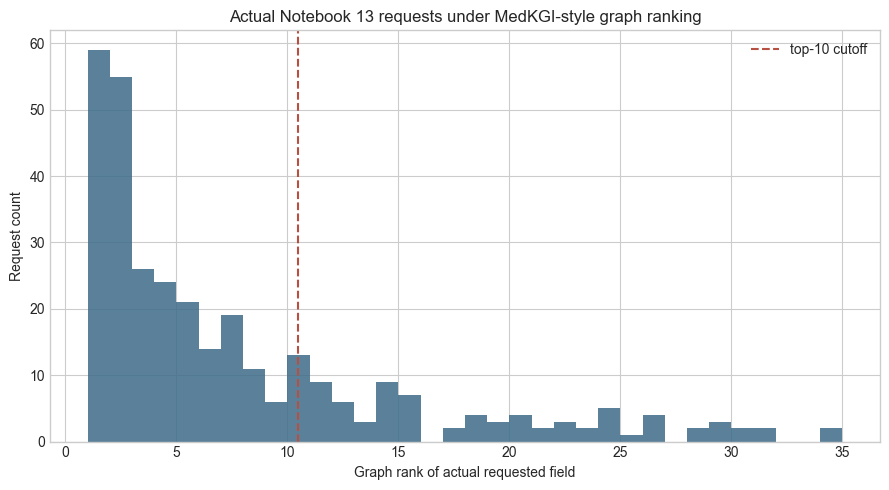

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_87928/4234064275.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=["wrong final", "correct final"], patch_artist=True)


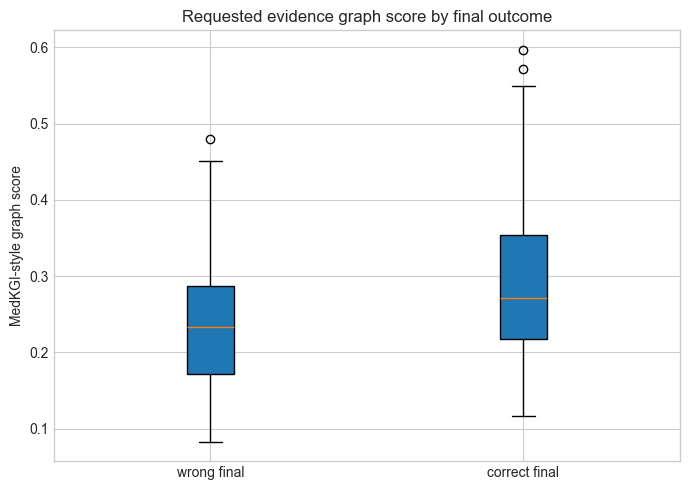

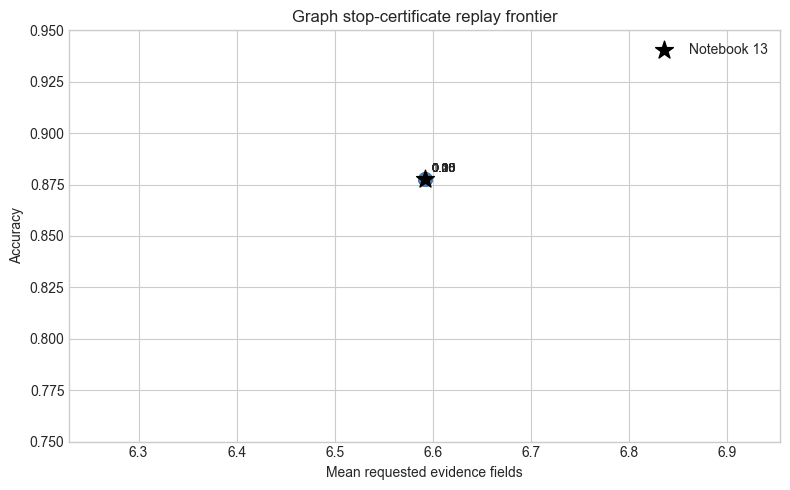

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_87928/4234064275.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=["wrong final", "correct final"], patch_artist=True)


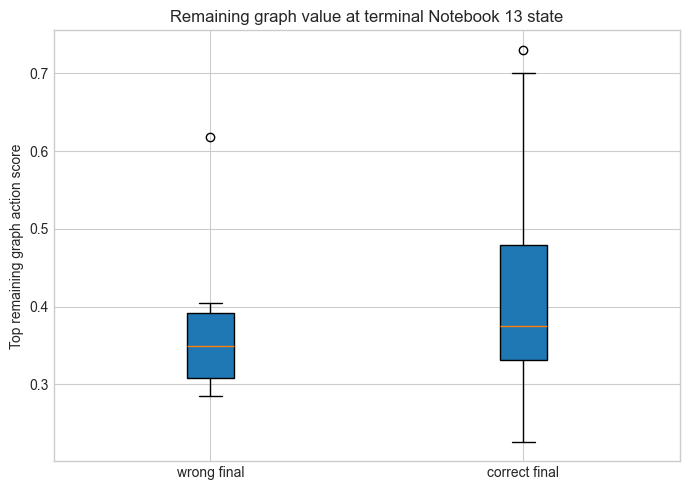

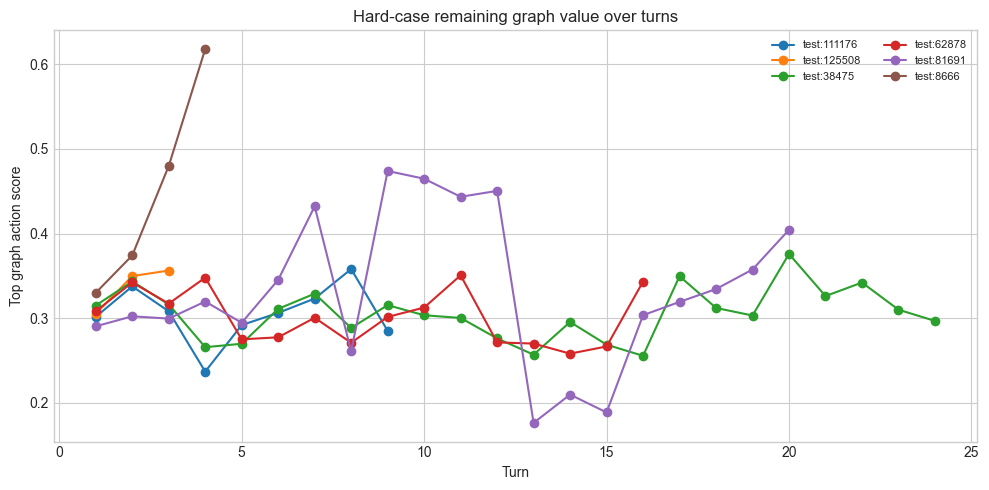

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")

# Figure 1: actual request graph rank distribution.
fig, ax = plt.subplots(figsize=(9, 5))
rank_values = actual_request_graph_rank["actual_request_graph_rank"].dropna()
ax.hist(rank_values, bins=range(1, int(min(60, max(rank_values.max() if len(rank_values) else 1, 2))) + 2), color="#3E6B89", alpha=0.85)
ax.axvline(10.5, color="#B85042", linestyle="--", label="top-10 cutoff")
ax.set_title("Actual Notebook 13 requests under MedKGI-style graph ranking")
ax.set_xlabel("Graph rank of actual requested field")
ax.set_ylabel("Request count")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "actual_request_graph_rank_distribution.png", dpi=180)
plt.show()

# Figure 2: correct vs wrong request quality.
fig, ax = plt.subplots(figsize=(7, 5))
plot_data = actual_request_graph_rank.dropna(subset=["actual_request_graph_score"]).copy()
labels = [False, True]
box_data = [plot_data.loc[plot_data["notebook13_final_correct"] == label, "actual_request_graph_score"] for label in labels]
ax.boxplot(box_data, labels=["wrong final", "correct final"], patch_artist=True)
ax.set_title("Requested evidence graph score by final outcome")
ax.set_ylabel("MedKGI-style graph score")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "request_score_correct_vs_wrong.png", dpi=180)
plt.show()

# Figure 3: stop frontier.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(graph_stop_replay_summary["mean_requests"], graph_stop_replay_summary["accuracy"], s=90, color="#4F7CAC")
for _, row in graph_stop_replay_summary.iterrows():
    ax.annotate(f"{row['info_threshold']:.2f}", (row["mean_requests"], row["accuracy"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.scatter([notebook13_metrics["mean_requests"]], [notebook13_metrics["accuracy"]], marker="*", s=180, color="black", label="Notebook 13")
ax.set_title("Graph stop-certificate replay frontier")
ax.set_xlabel("Mean requested evidence fields")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.75, 0.95)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "graph_stop_replay_frontier.png", dpi=180)
plt.show()

# Figure 4: terminal graph score for correct vs wrong cases.
fig, ax = plt.subplots(figsize=(7, 5))
terminal = case_terminal_graph_state.copy()
box_data = [terminal.loc[terminal["notebook13_correct"] == label, "terminal_top_graph_score"] for label in labels]
ax.boxplot(box_data, labels=["wrong final", "correct final"], patch_artist=True)
ax.set_title("Remaining graph value at terminal Notebook 13 state")
ax.set_ylabel("Top remaining graph action score")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "terminal_graph_score_correct_vs_wrong.png", dpi=180)
plt.show()

# Figure 5: hard case graph score timelines.
if audit_case_ids:
    fig, ax = plt.subplots(figsize=(10, 5))
    for case_id in audit_case_ids:
        turns = turn_level_graph_state[turn_level_graph_state["case_id"] == case_id].sort_values("turn_index")
        ax.plot(turns["turn_index"], turns["top_graph_score"], marker="o", label=case_id)
    ax.set_title("Hard-case remaining graph value over turns")
    ax.set_xlabel("Turn")
    ax.set_ylabel("Top graph action score")
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "hard_case_graph_score_timelines.png", dpi=180)
    plt.show()


## 10. Final Summary And Artifact Contract


In [13]:
summary_payload = {
    "notebook": "16_graph_algorithmic_evidence_ledger_offline_analysis.ipynb",
    "method": "MedKGI-style DDXPlus-native graph evidence ledger offline replay",
    "source_notebook13_run": str(NOTEBOOK13_RUN),
    "artifact_root": str(ARTIFACT_ROOT),
    "train_rows_for_graph_stats": graph_stats.train_rows,
    "num_pathologies": len(pathology_labels),
    "num_root_evidence_fields": len(root_ids),
    "max_outcome_states_per_root": MAX_OUTCOME_STATES_PER_ROOT,
    "notebook13_reference": {
        "accuracy": float(notebook13_metrics["accuracy"]),
        "top3_accuracy": float(notebook13_metrics["top3_accuracy"]),
        "top5_accuracy": float(notebook13_metrics["top5_accuracy"]),
        "mean_requests": float(notebook13_metrics["mean_requests"]),
        "correct_count": int(round(float(notebook13_metrics["accuracy"]) * len(notebook13_predictions))),
        "num_cases": int(len(notebook13_predictions)),
    },
    "request_quality_summary": request_quality_summary.to_dict(orient="records"),
    "selected_graph_policy": selected_policy,
    "offline_limitations": [
        "No API calls are made, so this notebook cannot observe how the LLM would ask different future questions under a graph shortlist.",
        "Policies that require continuing past an early Notebook 13 stop are marked as trace-limited rather than claimed as improved.",
        "True labels are used only after scoring for evaluation and hard-case reporting.",
    ],
    "promotion_decision": {
        "ready_for_live_notebook17": bool(
            selected_policy.get("correct_count", 0) >= 43
            and selected_policy.get("mean_requests", 999.0) <= float(notebook13_metrics["mean_requests"])
            and len(hard_case_summary) > 0
        ),
        "recommended_live_scope": "conditional_graph_shortlist_pilot_not_stop_policy_replacement",
        "reason": "Graph action scores are informative and highlight low-yield trajectories in hard cases; offline stop replay alone does not prove a better stop policy.",
        "do_not_claim_offline_stop_improvement": True,
    },
}
write_json(ARTIFACT_ROOT / "resolved_run_config.json", {
    "random_seed": RANDOM_SEED,
    "active_k": ACTIVE_K,
    "shortlist_size": SHORTLIST_SIZE,
    "alpha": ALPHA,
    "max_outcome_states_per_root": MAX_OUTCOME_STATES_PER_ROOT,
    "score_weights": {
        "information_gain": INFO_GAIN_WEIGHT,
        "split_balance": SPLIT_BALANCE_WEIGHT,
        "global_mi": GLOBAL_MI_WEIGHT,
    },
    "base_stop_policy": BASE_STOP_POLICY,
    "graph_info_thresholds": GRAPH_INFO_THRESHOLDS,
    "dataset_dir": str(DATASET_DIR),
    "source_run": str(NOTEBOOK13_RUN),
})
write_json(ARTIFACT_ROOT / "analysis_summary.json", summary_payload)

print("Saved artifacts to", ARTIFACT_ROOT)
print(json.dumps(summary_payload["promotion_decision"], indent=2))


Saved artifacts to /Users/bilalawan/claw/assignments/baseline_model/artifacts/graph_algorithmic_ledger/medkgi_style_offline_notebook13_49case_v1
{
  "ready_for_live_notebook17": true,
  "recommended_live_scope": "conditional_graph_shortlist_pilot_not_stop_policy_replacement",
  "reason": "Graph action scores are informative and highlight low-yield trajectories in hard cases; offline stop replay alone does not prove a better stop policy.",
  "do_not_claim_offline_stop_improvement": true
}
